In [81]:
#1
from google.colab import files
uploaded=files.upload()

Saving german.data to german (2).data


In [82]:
#2
import pandas as pd

df = pd.read_csv("german.data", sep=" ", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [83]:
#3
import pandas as pd
columns = [
    "CheckingAccount", "Duration", "CreditHistory", "Purpose",
    "CreditAmount", "SavingsAccount", "EmploymentSince",
    "InstallmentRate", "PersonalStatusSex", "OtherDebtors",
    "ResidenceSince", "Property", "Age",
    "OtherInstallmentPlans", "Housing",
    "ExistingCredits", "Job", "Dependents",
    "Telephone", "ForeignWorker", "Risk"
]
df = pd.read_csv("german.data", sep=" ", header=None)
df.columns = columns

df.head()

,CheckingAccount,Duration,CreditHistory,Purpose,CreditAmount,SavingsAccount,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Dependents,Telephone,ForeignWorker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [84]:
#4
df["Risk"] = df["Risk"].map({1: "Low Risk", 2: "High Risk"})
df["Risk"].value_counts()

,count
Risk,
Low Risk,700
High Risk,300


In [85]:
#5
# Step 1: Separate target
y = df["Risk"]

# Step 2: Features
X = df.drop("Risk", axis=1)

# Step 3: Encode only features
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 4: Convert target to numeric
y_encoded = y.map({"Low Risk":0, "High Risk":1})

X_encoded.head()

,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Dependents,CheckingAccount_A12,CheckingAccount_A13,CheckingAccount_A14,...,Property_A124,OtherInstallmentPlans_A142,OtherInstallmentPlans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,ForeignWorker_A202
0,6,1169,4,4,67,2,1,False,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,True,False,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,False,False,True,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,False,False,False,...,True,False,True,False,True,False,True,False,False,False


In [86]:
#6

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [87]:
#7
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [88]:
#8
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42
)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_model

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [89]:

#9
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

# train model
rf_model.fit(X_train, y_train)

# make predictions
rf_pred = rf_model.predict(X_test)

In [90]:
#10
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,50),
    max_iter=700,
    random_state=42
)
mlp_model.fit(X_train, y_train)

mlp_pred = mlp_model.predict(X_test)
mlp_model

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=700, random_state=42)

In [91]:
#11
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

log_results = evaluate_model(log_model)
rf_results = evaluate_model(rf_model)
mlp_results = evaluate_model(mlp_model)

In [92]:
#12
results_table = pd.DataFrame([
    log_results,
    rf_results,
    mlp_results
], index=["Logistic Regression", "Random Forest", "Neural Network"])

results_table

,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.750,0.558140,0.800000,0.657534,0.803095
Random Forest,0.750,0.596154,0.516667,0.553571,0.799524
Neural Network,0.775,0.627119,0.616667,0.621849,0.812619


In [93]:
#13
print(X_encoded.columns)
X_encoded.shape

Index(['Duration', 'CreditAmount', 'InstallmentRate', 'ResidenceSince', 'Age',
       'ExistingCredits', 'Dependents', 'CheckingAccount_A12',
       'CheckingAccount_A13', 'CheckingAccount_A14', 'CreditHistory_A31',
       'CreditHistory_A32', 'CreditHistory_A33', 'CreditHistory_A34',
       'Purpose_A41', 'Purpose_A410', 'Purpose_A42', 'Purpose_A43',
       'Purpose_A44', 'Purpose_A45', 'Purpose_A46', 'Purpose_A48',
       'Purpose_A49', 'SavingsAccount_A62', 'SavingsAccount_A63',
       'SavingsAccount_A64', 'SavingsAccount_A65', 'EmploymentSince_A72',
       'EmploymentSince_A73', 'EmploymentSince_A74', 'EmploymentSince_A75',
       'PersonalStatusSex_A92', 'PersonalStatusSex_A93',
       'PersonalStatusSex_A94', 'OtherDebtors_A102', 'OtherDebtors_A103',
       'Property_A122', 'Property_A123', 'Property_A124',
       'OtherInstallmentPlans_A142', 'OtherInstallmentPlans_A143',
       'Housing_A152', 'Housing_A153', 'Job_A172', 'Job_A173', 'Job_A174',
       'Telephone_A192', 'Foreig

(1000, 48)

In [94]:
#14
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print(coef_df.head(10))

            feature  coefficient
38    Property_A124     0.422324
1      CreditAmount     0.405536
2   InstallmentRate     0.381396
0          Duration     0.301863
44         Job_A173     0.236672
43         Job_A172     0.199846
45         Job_A174     0.138203
20      Purpose_A46     0.134633
37    Property_A123     0.116603
6        Dependents     0.106617


In [95]:
#15
wrong_mask = (mlp_pred != y_test)

X_test_df = X_encoded.loc[y_test.index]

X_wrong = X_test_df[wrong_mask]
y_wrong = y_test[wrong_mask]

print("Wrong predictions:", len(X_wrong))

Wrong predictions: 45


In [96]:
#16
from sklearn.tree import DecisionTreeClassifier

rule_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

rule_tree.fit(X_wrong, y_wrong)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [97]:
#17
from sklearn.tree import export_text

rules = export_text(rule_tree, feature_names=list(X_wrong.columns))
print(rules)

|--- CreditHistory_A32 <= 0.50
|   |--- Dependents <= 1.50
|   |   |--- ResidenceSince <= 1.50
|   |   |   |--- class: 0
|   |   |--- ResidenceSince >  1.50
|   |   |   |--- class: 1
|   |--- Dependents >  1.50
|   |   |--- OtherInstallmentPlans_A143 <= 0.50
|   |   |   |--- class: 0
|   |   |--- OtherInstallmentPlans_A143 >  0.50
|   |   |   |--- class: 1
|--- CreditHistory_A32 >  0.50
|   |--- Purpose_A49 <= 0.50
|   |   |--- CreditAmount <= 1694.50
|   |   |   |--- class: 1
|   |   |--- CreditAmount >  1694.50
|   |   |   |--- class: 0
|   |--- Purpose_A49 >  0.50
|   |   |--- class: 1



In [98]:
#18
def rule_engine_with_confidence(row, ml_prediction, probability):

    final_prediction = ml_prediction
    explanations = []

    if 0.35 <= probability <= 0.65:

        sample = row.values.reshape(1, -1)   # ✅ FIX ADDED

        tree_pred = rule_tree.predict(sample)[0]

        if tree_pred != ml_prediction:
            final_prediction = tree_pred

            node_indicator = rule_tree.decision_path(sample)
            feature = rule_tree.tree_.feature
            threshold = rule_tree.tree_.threshold

            for node_id in node_indicator.indices:

                if feature[node_id] != -2:
                    fname = feature_names[feature[node_id]]

                    if fname in top_features:

                        thresh = threshold[node_id]
                        val = row[fname]

                        if val <= thresh:
                            explanations.append(f"{fname} <= {round(thresh,2)}")
                        else:
                            explanations.append(f"{fname} > {round(thresh,2)}")

            explanations.append(
                f"Decision Tree override: predicted {tree_pred} instead of {ml_prediction}"
            )

            explanations.append(
                f"NN confidence {round(probability,2)} in uncertain range"
            )

    return final_prediction, explanations

In [99]:
#19
def get_ml_explanation(sample, model, feature_names):
    coefs = model.coef_[0]
    contributions = sample * coefs

    explanation = []
    for i in range(len(feature_names)):
        explanation.append((feature_names[i], contributions[0][i]))

    # sort by impact
    explanation = sorted(explanation, key=lambda x: abs(x[1]), reverse=True)

    return explanation[:5]  # top 5 reasons

In [100]:
#20
import numpy as np

importances = rule_tree.feature_importances_
feature_names = list(X_test_df.columns)

top_k = 5
top_features_idx = np.argsort(importances)[-top_k:]
top_features = [feature_names[i] for i in top_features_idx]

ns_predictions = []
explanations_list = []

for i in range(len(X_test)):

    row = X_test_df.iloc[i]
    sample_scaled = X_test[i:i+1]

    # ML prediction (Neural Net)
    ml_pred = mlp_model.predict(sample_scaled)[0]
    prob = mlp_model.predict_proba(sample_scaled)[0][1]

    # ML explanation (use Logistic Regression)
    ml_expl = get_ml_explanation(sample_scaled, log_model, list(X.columns))

    # Symbolic rules
    final_pred, rule_expl = rule_engine_with_confidence(row, ml_pred, prob)

    ns_predictions.append(final_pred)

    explanations_list.append({
        "index": i,
        "ml_pred": ml_pred,
        "ml_prob": prob,
        "ml_reason": ml_expl,
        "rule_reason": rule_expl,
        "final_pred": final_pred,
        "changed": final_pred != ml_pred
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [101]:
#21
for case in explanations_list:

    print("\n==============================")
    print(f"Index: {case['index']}")

    print(f"\nML Prediction: {case['ml_pred']} (prob={case['ml_prob']:.2f})")
    print("Top ML Reasons:")

    for f, val in case["ml_reason"]:
        direction = "increased risk" if val > 0 else "reduced risk"
        print(f" - {f}: {round(val,2)} ({direction})")

    print("\nRule Reason:")
    for r in case["rule_reason"]:
        print(" -", r)

    print(f"\nFinal Prediction: {case['final_pred']}")

    if case["changed"]:
        print(" Changed by symbolic rules")


Index: 0

ML Prediction: 0 (prob=0.00)
Top ML Reasons:
 - OtherDebtors: 0.66 (increased risk)
 - OtherInstallmentPlans: 0.45 (increased risk)
 - Property: -0.32 (reduced risk)
 - InstallmentRate: -0.29 (reduced risk)
 - Dependents: 0.2 (increased risk)

Rule Reason:

Final Prediction: 0

Index: 1

ML Prediction: 0 (prob=0.00)
Top ML Reasons:
 - Housing: -1.32 (reduced risk)
 - OtherInstallmentPlans: -1.05 (reduced risk)
 - OtherDebtors: 0.66 (increased risk)
 - CreditHistory: 0.36 (increased risk)
 - Property: 0.35 (increased risk)

Rule Reason:

Final Prediction: 0

Index: 2

ML Prediction: 1 (prob=1.00)
Top ML Reasons:
 - OtherDebtors: 0.66 (increased risk)
 - Age: -0.6 (reduced risk)
 - Dependents: -0.54 (reduced risk)
 - OtherInstallmentPlans: 0.45 (increased risk)
 - CreditHistory: 0.36 (increased risk)

Rule Reason:

Final Prediction: 1

Index: 3

ML Prediction: 0 (prob=0.06)
Top ML Reasons:
 - OtherDebtors: 0.66 (increased risk)
 - OtherInstallmentPlans: 0.45 (increased risk)
 

In [102]:
#22
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network",
        "Neuro-Symbolic"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, mlp_pred),
        accuracy_score(y_test, ns_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, mlp_pred),
        precision_score(y_test, ns_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, mlp_pred),
        recall_score(y_test, ns_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, mlp_pred),
        f1_score(y_test, ns_predictions)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression     0.750   0.558140  0.800000  0.657534
1        Random Forest     0.750   0.596154  0.516667  0.553571
2       Neural Network     0.775   0.627119  0.616667  0.621849
3       Neuro-Symbolic     0.795   0.666667  0.633333  0.649573


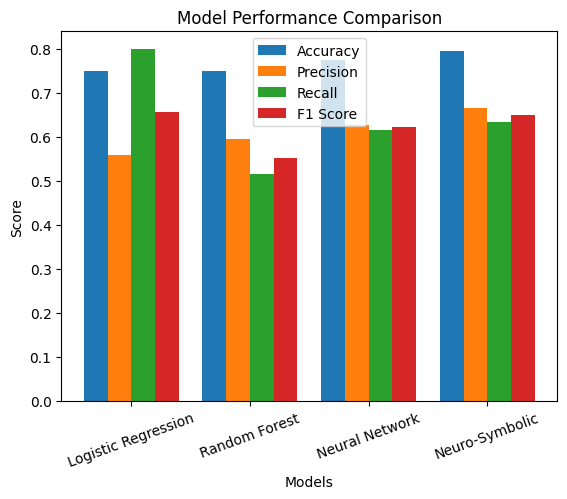

In [103]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(results["Model"]))
width = 0.2

plt.figure()

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5)*width, results[metric], width, label=metric)

plt.xticks(x, results["Model"], rotation=20)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()